In [1]:
import numpy as np
import pandas as pd
import os

DATA_DIR = os.path.join(os.getcwd(), "Embedding", "CobaData")

In [2]:
# ── Load data hasil augmentasi Mixup ─────────────────────────────────────────
questions_emb  = np.load(os.path.join(DATA_DIR, 'questions_emb.npy'))
answerkeys_emb = np.load(os.path.join(DATA_DIR, 'answerkeys_emb.npy'))
answers_emb    = np.load(os.path.join(DATA_DIR, 'answers_emb.npy'))
metadata       = pd.read_pickle(os.path.join(DATA_DIR, 'metadata.pkl'))
metadata       = metadata.reset_index(drop=True)
metadata['is_synthetic'] = False  # tandai data asli

print("=== Hasil Load ===")
print(f"questions_emb  : {questions_emb.shape}")
print(f"answerkeys_emb : {answerkeys_emb.shape}")
print(f"answers_emb    : {answers_emb.shape}")
print(f"Metadata       : {len(metadata)} rows")

=== Hasil Load ===
questions_emb  : (26, 135, 300)
answerkeys_emb : (26, 125, 300)
answers_emb    : (1778, 80, 300)
Metadata       : 1778 rows


In [3]:
# ── Analisis lubang (grade = 0 sampel per IDPSJ) ──────────────────────────────
pivot = (metadata.groupby(['IDPSJ', 'grade'])
                 .size()
                 .unstack(fill_value=0)
                 .reindex(columns=range(1, 11), fill_value=0))

print("Distribusi sebelum Cross-Prompt Injection:")
print(pivot.to_string())

# Daftar lubang: (IDPSJ_target, grade)
holes = [(psj, g)
         for psj in pivot.index
         for g in range(1, 11)
         if pivot.loc[psj, g] < 2] # coba
        #  if pivot.loc[psj, g] == 0] # sekarang

print(f"\nTotal lubang (grade=0): {len(holes)}")
for h in holes:
    print(f"  IDPSJ {h[0]:>2}  grade {h[1]}")

Distribusi sebelum Cross-Prompt Injection:
grade  1   2   3   4   5   6   7   8   9   10
IDPSJ                                        
1       9   1   0   9   1  25   3  11   5  37
2       1   0  15   0   5   5   0  10   0   5
3       5   0   0   4   1  10   0   6   0   7
4       0   5   5  15   1  10  10   0   3  17
5      17   4   7   0   5   5   2   3   5   5
6      22   4   4   5   5  10   5   5   4   7
7       6   0   3   0   8  10   4   6   3  17
8       0   0  12   6  11   7   3  10  10  53
9      14   0   9   9   1  10  10   2   1  47
10      5   8   0  10   0  10  18  23  19  21
11      6  42  17   0  10   0  13  10   0  22
12      4   0   1   0   5   0  21   6   6   2
13      9   1   0   6   3  11   0  20   2   8
14      9   2   0   6   2  12   5  15   3   9
15     11   5   9   9   1  10   1   9   0  10
16      5   4   2   8   4   8   5  10   7   3
17     27   2   0   3   7   9   3   8   1   9
18      8   4   0   6  10  10   6   4   9   4
19      5   4   2   6   9  10   6   4

In [4]:
# ── Cross-Prompt Injection ────────────────────────────────────────────────────
# Strategi:
#   Untuk setiap (IDPSJ_target, grade_target) dengan count < 2:
#   1. Hitung target = ceil(max_cls_IDPSJ / 2)  → konsisten dengan Mixup
#   2. n_inject = target - current_count  → tidak overshoot jika sudah ada 1 sampel
#   3. Cari donor: IDPSJ lain yang PUNYA grade_target
#   4. Ambil n_inject answer embeddings dari donor (acak, dengan penggantian)
#   5. Pasangkan dengan question & answerkey milik IDPSJ_target
#   6. Label tetap = grade_target

RNG = np.random.default_rng(seed=42)

inj_answers = []
inj_meta    = []

for (tgt_psj, tgt_grade) in holes:
    # Target per kelas = ceil(max kelas IDPSJ ini / 2)  — sama dengan Mixup
    local_max = pivot.loc[tgt_psj].max()
    target    = int(np.ceil(local_max / 2))
    n_inject  = target - pivot.loc[tgt_psj, tgt_grade]  # kurangi yang sudah ada

    if n_inject <= 0:
        continue

    # Cari donor: IDPSJ lain yang punya grade_target
    donor_mask = (
        (metadata['IDPSJ'] != tgt_psj) &
        (metadata['grade'] == tgt_grade)
    )
    donor_idx = metadata.index[donor_mask].values

    if len(donor_idx) == 0:
        print(f"  [SKIP] IDPSJ={tgt_psj} grade={tgt_grade} — tidak ada donor!")
        continue

    cur = pivot.loc[tgt_psj, tgt_grade]
    print(f"  IDPSJ={tgt_psj} grade={tgt_grade}  cur={cur}  target={target}  n_inject={n_inject}  donor={len(donor_idx)}")

    # Ambil n_inject sampel dari donor (dengan penggantian jika donor sedikit)
    sampled = RNG.choice(donor_idx, size=n_inject, replace=len(donor_idx) < n_inject)

    # Hanya answers yang diambil dari donor; questions & answerkeys tetap per IDPSJ
    inj_answers.append(answers_emb[sampled])

    for k in range(n_inject):
        inj_meta.append({
            'IDJwb'        : f'cpi_{tgt_psj}_{tgt_grade}_{k}',
            'IDPSJ'        : tgt_psj,
            'grade'        : tgt_grade,
            'is_synthetic' : True,
        })

# ── Gabungkan ─────────────────────────────────────────────────────────────────
if inj_answers:
    final_answers_emb = np.vstack([answers_emb] + inj_answers)
    final_metadata    = pd.concat([metadata, pd.DataFrame(inj_meta)],
                                  ignore_index=True)
else:
    final_answers_emb = answers_emb.copy()
    final_metadata    = metadata.copy()

# questions & answerkeys tidak diubah — sudah satu baris per IDPSJ
final_questions_emb  = questions_emb   # (17, 135, 300)
final_answerkeys_emb = answerkeys_emb  # (17, 90, 300)

n_inj = len(final_metadata) - len(metadata)
print(f"\nData sebelum CPI : {len(metadata)}")
print(f"Data injeksi CPI : {n_inj}")
print(f"Total akhir      : {len(final_metadata)}")
print(f"\nfinal_answers_emb    : {final_answers_emb.shape}")
print(f"final_questions_emb  : {final_questions_emb.shape}")
print(f"final_answerkeys_emb : {final_answerkeys_emb.shape}")

  IDPSJ=1 grade=2  cur=1  target=19  n_inject=18  donor=115
  IDPSJ=1 grade=3  cur=0  target=19  n_inject=19  donor=99
  IDPSJ=1 grade=5  cur=1  target=19  n_inject=18  donor=121
  IDPSJ=2 grade=1  cur=1  target=8  n_inject=7  donor=199
  IDPSJ=2 grade=2  cur=0  target=8  n_inject=8  donor=116
  IDPSJ=2 grade=4  cur=0  target=8  n_inject=8  donor=145
  IDPSJ=2 grade=7  cur=0  target=8  n_inject=8  donor=145
  IDPSJ=2 grade=9  cur=0  target=8  n_inject=8  donor=145
  IDPSJ=3 grade=2  cur=0  target=5  n_inject=5  donor=116
  IDPSJ=3 grade=3  cur=0  target=5  n_inject=5  donor=99
  IDPSJ=3 grade=5  cur=1  target=5  n_inject=4  donor=121
  IDPSJ=3 grade=7  cur=0  target=5  n_inject=5  donor=145
  IDPSJ=3 grade=9  cur=0  target=5  n_inject=5  donor=145
  IDPSJ=4 grade=1  cur=0  target=9  n_inject=9  donor=200
  IDPSJ=4 grade=5  cur=1  target=9  n_inject=8  donor=121
  IDPSJ=4 grade=8  cur=0  target=9  n_inject=9  donor=233
  IDPSJ=5 grade=4  cur=0  target=9  n_inject=9  donor=145
  IDPSJ=7 

Distribusi setelah Cross-Prompt Injection:
grade  1   2   3   4   5   6   7   8   9   10
IDPSJ                                        
1       9  19  19   9  19  25   3  11   5  37
2       8   8  15   8   5   5   8  10   8   5
3       5   5   5   4   5  10   5   6   5   7
4       9   5   5  15   9  10  10   9   3  17
5      17   4   7   9   5   5   2   3   5   5
6      22   4   4   5   5  10   5   5   4   7
7       6   9   3   9   8  10   4   6   3  17
8      27  27  12   6  11   7   3  10  10  53
9      14  24   9   9  24  10  10   2  24  47
10      5   8  12  10  12  10  18  23  19  21
11      6  42  17  21  10  21  13  10  21  22
12      4  11  11  11   5  11  21   6   6   2
13      9  10  10   6   3  11  10  20   2   8
14      9   2   8   6   2  12   5  15   3   9
15     11   5   9   9   6  10   6   9   6  10
16      5   4   2   8   4   8   5  10   7   3
17     27   2  14   3   7   9   3   8  14   9
18      8   4   5   6  10  10   6   4   9   4
19      5   4   2   6   9  10   6   4

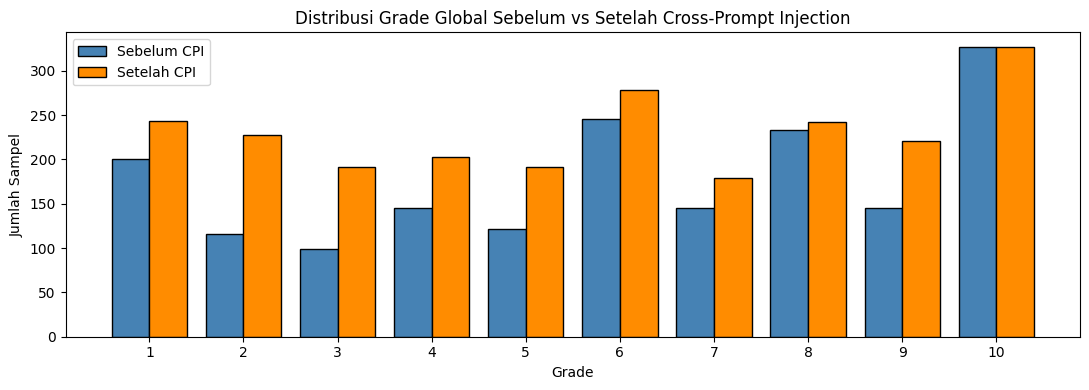

In [5]:
# ── Verifikasi distribusi setelah CPI ─────────────────────────────────────────
import matplotlib.pyplot as plt

pivot_final = (final_metadata.groupby(['IDPSJ', 'grade'])
                             .size()
                             .unstack(fill_value=0)
                             .reindex(columns=range(1, 11), fill_value=0))

print("Distribusi setelah Cross-Prompt Injection:")
print(pivot_final.to_string())

sisa_holes = [(psj, g)
              for psj in pivot_final.index
              for g in range(1, 11)
              if pivot_final.loc[psj, g] == 0]
print(f"\nSisa lubang setelah CPI: {len(sisa_holes)}")
if sisa_holes:
    for h in sisa_holes:
        print(f"  IDPSJ={h[0]} grade={h[1]} — tidak ada donor di seluruh dataset")

# Bar chart distribusi global sebelum vs sesudah
before = metadata['grade'].value_counts().sort_index()
after  = final_metadata['grade'].value_counts().sort_index()

x = np.arange(1, 11)
w = 0.4
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(x - w/2, [before.get(g, 0) for g in x], w, label='Sebelum CPI', color='steelblue',  edgecolor='black')
ax.bar(x + w/2, [after.get(g,  0) for g in x], w, label='Setelah CPI', color='darkorange', edgecolor='black')
ax.set_xticks(x)
ax.set_xlabel('Grade')
ax.set_ylabel('Jumlah Sampel')
ax.set_title('Distribusi Grade Global Sebelum vs Setelah Cross-Prompt Injection')
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
# ── Simpan hasil akhir ───────────────────────────────────────────────────────
# answers_emb : simpan penuh karena setiap sampel unik
# questions & answerkeys : satu baris per IDPSJ (tidak berubah setelah CPI)
#   → rekonstruksi di training menggunakan kolom psj_idx di metadata

# Buat mapping IDPSJ → indeks unik (harus konsisten dengan urutan questions_emb)
idpsj_sorted  = sorted(final_metadata['IDPSJ'].unique())
idpsj_to_idx  = {psj: i for i, psj in enumerate(idpsj_sorted)}
final_metadata = final_metadata.copy()
final_metadata['psj_idx'] = final_metadata['IDPSJ'].map(idpsj_to_idx)

# Simpan
np.save(os.path.join(DATA_DIR, 'final_answers_emb.npy'),    final_answers_emb)
np.save(os.path.join(DATA_DIR, 'final_questions_emb.npy'),  final_questions_emb)
np.save(os.path.join(DATA_DIR, 'final_answerkeys_emb.npy'), final_answerkeys_emb)
final_metadata.to_pickle(os.path.join(DATA_DIR, 'final_metadata.pkl'))

print("File tersimpan:")
print(f"  final_answers_emb.npy      {final_answers_emb.shape}  (per sampel)")
print(f"  final_questions_emb.npy    {final_questions_emb.shape}  (per IDPSJ)")
print(f"  final_answerkeys_emb.npy   {final_answerkeys_emb.shape}  (per IDPSJ)")
print(f"  final_metadata.pkl         {len(final_metadata)} rows  (+ kolom psj_idx)")

File tersimpan:
  final_answers_emb.npy      (2304, 80, 300)  (per sampel)
  final_questions_emb.npy    (26, 135, 300)  (per IDPSJ)
  final_answerkeys_emb.npy   (26, 125, 300)  (per IDPSJ)
  final_metadata.pkl         2304 rows  (+ kolom psj_idx)
